## Contribution
Author: Justin Brown

Dated: 08/05/2025

### TODOs - Dated: 08/05/2025
1. Organize and clean this notebook.
2. Train the best possible tuned model with current understanding.
3. Compare peformance with Rachel's algorithm detector on the same exact dataset.

# Setup Stage

In [121]:
# Required dependencies
!python --version
!pip install pip==25.1.1

# MUST restart the session when prompted before moving forward.
!pip install mediapipe-model-maker

Python 3.11.13


# Useful functions

In [ ]:
# Was used initially to bypass some version issues that don't happen anymore.
# Probably not needed but kept here just in case.
# !pip install -q mediapipe==0.10.20 numpy==1.26.4 tensorflow==2.18

In [ ]:
"""Taken from the mediapipe GitHub. Added a sort to all_image_paths, and
changed imports for model_maker - Justin Brown"""
# Copyright 2022 The MediaPipe Authors.
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.
"""Gesture recognition dataset library."""

import dataclasses
import os
import random
from typing import List, Optional

import tensorflow as tf

from mediapipe_model_maker.python.core.data import classification_dataset
from mediapipe_model_maker.python.core.utils import model_util
from mediapipe_model_maker.python.vision.gesture_recognizer import constants
from mediapipe_model_maker.python.vision.gesture_recognizer import metadata_writer
from mediapipe.python._framework_bindings import image as image_module
from mediapipe.tasks.python.core import base_options as base_options_module
from mediapipe.tasks.python.vision import hand_landmarker as hand_landmarker_module

_Image = image_module.Image
_HandLandmarker = hand_landmarker_module.HandLandmarker
_HandLandmarkerOptions = hand_landmarker_module.HandLandmarkerOptions
_HandLandmarkerResult = hand_landmarker_module.HandLandmarkerResult


@dataclasses.dataclass
class HandDataPreprocessingParams:
  """A dataclass wraps the hand data preprocessing hyperparameters.

  Attributes:
    shuffle: A boolean controlling if shuffle the dataset. Default to true.
    min_detection_confidence: confidence threshold for hand detection.
  """
  shuffle: bool = True
  min_detection_confidence: float = 0.7


@dataclasses.dataclass
class HandData:
  """A dataclass represents hand data for training gesture recognizer model.

  See https://google.github.io/mediapipe/solutions/hands#mediapipe-hands for
  more details of the hand gesture data API.

  Attributes:
    hand: normalized hand landmarks of shape 21x3 from the screen based
      hand-landmark model.
    world_hand: hand landmarks of shape 21x3 in world coordinates.
    handedness: Collection of handedness confidence of the detected hands (i.e.
      is it a left or right hand).
  """
  hand: List[List[float]]
  world_hand: List[List[float]]
  handedness: List[float]


def _validate_data_sample(data: _HandLandmarkerResult) -> bool:
  """Validates the input hand data sample.

  Args:
    data: input hand data sample.

  Returns:
    False if the input data namedtuple does not contain the fields including
    'multi_hand_landmarks' or 'multi_hand_world_landmarks' or 'multi_handedness'
    or any of these attributes' values are none. Otherwise, True.
  """
  if data.hand_landmarks is None or not data.hand_landmarks:
    return False
  if data.hand_world_landmarks is None or not data.hand_world_landmarks:
    return False
  if data.handedness is None or not data.handedness:
    return False
  return True

# Justin Edit: Added min_hand_presence_confidence and min_tracking_confidence as
# parameters so it's possible to test on the full dataset.
def _get_hand_data(all_image_paths: List[str],
                   min_detection_confidence: float,
                   min_hand_presence_confidence: float = 0.5,
                   min_tracking_confidence: float = 1) -> List[Optional[HandData]]:
  """Computes hand data (landmarks and handedness) in the input image.

  Args:
    all_image_paths: all input image paths.
    min_detection_confidence: hand detection confidence threshold

  Returns:
    A HandData object. Returns None if no hand is detected.
  """
  hand_data_result = []
  hand_detector_model_buffer = model_util.load_tflite_model_buffer(
      constants.HAND_DETECTOR_TFLITE_MODEL_FILE.get_path()
  )
  hand_landmarks_detector_model_buffer = model_util.load_tflite_model_buffer(
      constants.HAND_LANDMARKS_DETECTOR_TFLITE_MODEL_FILE.get_path()
  )
  hand_landmarker_writer = metadata_writer.HandLandmarkerMetadataWriter(
      hand_detector_model_buffer, hand_landmarks_detector_model_buffer)

  # Justin Edit: changed min_detection_confidence and min_hand_presence_confidence
  # from default values to passed in values so that it's possible to test
  # on the full dataset without discarding any images.
  hand_landmarker_options = _HandLandmarkerOptions(
      base_options=base_options_module.BaseOptions(
          model_asset_buffer=hand_landmarker_writer.populate()),
      num_hands=1,
      min_hand_detection_confidence=min_detection_confidence,
      min_hand_presence_confidence=min_hand_presence_confidence,
      min_tracking_confidence=min_tracking_confidence,
  )
  with _HandLandmarker.create_from_options(
      hand_landmarker_options) as hand_landmarker:
    for path in all_image_paths:
      tf.compat.v1.logging.info('Loading image %s', path)
      image = _Image.create_from_file(path)
      data = hand_landmarker.detect(image)
      if not _validate_data_sample(data):
        hand_data_result.append(None)
        continue
      hand_landmarks = [[hand_landmark.x, hand_landmark.y, hand_landmark.z]
                        for hand_landmark in data.hand_landmarks[0]]
      hand_world_landmarks = [[
          hand_landmark.x, hand_landmark.y, hand_landmark.z
      ] for hand_landmark in data.hand_world_landmarks[0]]
      handedness_scores = [
          handedness.score for handedness in data.handedness[0]
      ]
      hand_data_result.append(
          HandData(
              hand=hand_landmarks,
              world_hand=hand_world_landmarks,
              handedness=handedness_scores))
  return hand_data_result


class DatasetJustin(classification_dataset.ClassificationDataset):
  """Dataset library for hand gesture recognizer."""

  @classmethod
  def from_folder(
      cls,
      dirname: str,
      hparams: Optional[HandDataPreprocessingParams] = None,
      min_hand_presence_confidence: float = 0.5,
      min_tracking_confidence: float = 1,
  ) -> classification_dataset.ClassificationDataset:
    """Loads images and labels from the given directory.

    Directory contents are expected to be in the format:
    <root_dir>/<gesture_name>/*.jpg". One of the `gesture_name` must be `none`
    (case insensitive). The `none` sub-directory is expected to contain images
    of hands that don't belong to other gesture classes in <root_dir>. Assumes
    the image data of the same label are in the same subdirectory.

    Args:
      dirname: Name of the directory containing the data files.
      hparams: Optional hyperparameters for processing input hand gesture
        images.

    Returns:
      Dataset containing landmarks, labels, and other related info.

    Raises:
      ValueError: if the input data directory is empty or the label set does not
        contain label 'none' (case insensitive).
    """
    data_root = os.path.abspath(dirname)

    # Assumes the image data of the same label are in the same subdirectory,
    # gets image path and label names.
    all_image_paths = sorted(tf.io.gfile.glob(data_root + r'/*/*'))
    if not all_image_paths:
      raise ValueError('Image dataset directory is empty.')

    if not hparams:
      hparams = HandDataPreprocessingParams()

    if hparams.shuffle:
      # Random shuffle data.
      random.shuffle(all_image_paths)

    label_names = sorted(
        name for name in os.listdir(data_root)
        if os.path.isdir(os.path.join(data_root, name)))
    if 'none' not in [v.lower() for v in label_names]:
      raise ValueError('Label set does not contain label "None".')
    # Move label 'none' to the front of label list.
    none_idx = [v.lower() for v in label_names].index('none')
    none_value = label_names.pop(none_idx)
    label_names.insert(0, none_value)

    index_by_label = dict(
        (name, index) for index, name in enumerate(label_names))
    all_gesture_indices = [
        index_by_label[os.path.basename(os.path.dirname(path))]
        for path in all_image_paths
    ]


    # Justin Edit: added min_detection_confidence and min_hand_presence_confidence
    # to passed in values so that it's possible to test on the full dataset
    # without discarding any images.

    # Compute hand data (including local hand landmark, world hand landmark, and
    # handedness) for all the input images.
    hand_data = _get_hand_data(
        all_image_paths=all_image_paths,
        min_detection_confidence=hparams.min_detection_confidence,
        min_hand_presence_confidence=min_hand_presence_confidence,
        min_tracking_confidence=min_tracking_confidence)

    # Get a list of the valid hand landmark sample in the hand data list.
    valid_indices = [
        i for i in range(len(hand_data)) if hand_data[i] is not None
    ]

    # Justin Edit: Testing
    print('Number of valid hand data was {} out of {}'.format(
        len(valid_indices), len(all_gesture_indices)))

    # Remove 'None' element from the hand data and label list.
    valid_hand_data = [dataclasses.asdict(hand_data[i]) for i in valid_indices]
    if not valid_hand_data:
      raise ValueError('No valid hand is detected.')

    valid_label = [all_gesture_indices[i] for i in valid_indices]

    # Convert list of dictionaries to dictionary of lists.
    hand_data_dict = {
        k: [lm[k] for lm in valid_hand_data] for k in valid_hand_data[0]
    }
    hand_ds = tf.data.Dataset.from_tensor_slices(hand_data_dict)

    embedder_model = model_util.load_keras_model(
        constants.GESTURE_EMBEDDER_KERAS_MODEL_FILES.get_path()
    )

    hand_ds = hand_ds.batch(batch_size=1)
    hand_embedding_ds = hand_ds.map(
        map_func=lambda feature: embedder_model(dict(feature)),
        num_parallel_calls=tf.data.experimental.AUTOTUNE)
    hand_embedding_ds = hand_embedding_ds.unbatch()

    # Create label dataset
    label_ds = tf.data.Dataset.from_tensor_slices(
        tf.cast(valid_label, tf.int64))

    label_one_hot_ds = label_ds.map(
        map_func=lambda index: tf.one_hot(index, len(label_names)),
        num_parallel_calls=tf.data.experimental.AUTOTUNE)

    # Create a dataset with (hand_embedding, one_hot_label) pairs
    hand_embedding_label_ds = tf.data.Dataset.zip(
        (hand_embedding_ds, label_one_hot_ds))

    tf.compat.v1.logging.info(
        'Load valid hands with size: {}, num_label: {}, labels: {}.'.format(
            len(valid_hand_data), len(label_names), ','.join(label_names)))
    return DatasetJustin(
        dataset=hand_embedding_label_ds,
        label_names=label_names,
        size=len(valid_hand_data),
    )

/usr/local/lib/python3.11/dist-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(


In [ ]:
"""
This function is meant specifically for the format that hagrid provides,
with an annotations.json file that gives bounding box values for each hand
and the gesture associated with that hand - Justin Brown
"""
import shutil
import json
import os
from PIL import Image

def crop_samples_to_bbox(dataset_path: str, output_path: str,
                         annotations_path: str, padding: float = 1.1):
  """
  Crops all the gesture images to just the hand, with some padding.

  Args:
    dataset_path (str): The path to the directory containing all gesture subdirectories of images
    output_path: The path to the directory where the cropped images will be
      saved.
    annotations_path: The path to the annotations.json file.
    padding: The amount of padding to add to the bounding box. A value of 1.1
      will make the bounding box 10% bigger.
  """
  selected_gestures = os.listdir(dataset_path) # All gestures selected by default

  with open(annotations_path, 'r') as f:
    annotations = json.load(f)
  if os.path.exists(output_path):
    shutil.rmtree(output_path)
  os.makedirs(output_path, exist_ok=True)
  for gesture in selected_gestures:
      gesture_output_dir = os.path.join(output_path, gesture)
      os.makedirs(gesture_output_dir, exist_ok=True)
      gesture_source_dir = os.path.join(dataset_path, gesture)
      if not os.path.isdir(gesture_source_dir):
          print(f"Skipping non-directory item: {gesture_source_dir}")
          continue
      if os.path.exists(gesture_source_dir):
          for filename in os.listdir(gesture_source_dir):
              image_path = os.path.join(gesture_source_dir, filename)
              image_key = os.path.splitext(filename)[0] # Get the image key without the extension

              if image_key in annotations[gesture] and annotations[gesture][image_key].get('bboxes'):
                  labels = annotations[gesture][image_key]['labels'] # (1 or 2 hands)

                  # Only gets the bboxes for hands that DON'T have 'no_gesture' as the label.
                  bboxes = [bbox for bbox, label in zip(annotations[gesture][image_key]['bboxes'], labels) if label == gesture]

                  for bbox in bboxes:
                    try:
                        img = Image.open(image_path).convert('RGB')
                        img_width, img_height = img.size
                        # Convert relative bounding box coordinates to absolute pixel coordinates
                        x_min_rel, y_min_rel, width_rel, height_rel = bbox
                        # Calculate the center of the bounding box
                        center_x = x_min_rel + width_rel / 2
                        center_y = y_min_rel + height_rel / 2
                        # Apply the padding to the width and height
                        new_width_rel = width_rel * padding
                        new_height_rel = height_rel * padding
                        # Calculate the new top-left corner
                        new_x_min_rel = center_x - new_width_rel / 2
                        new_y_min_rel = center_y - new_height_rel / 2
                        # Convert back to absolute pixel coordinates
                        x_min = int(new_x_min_rel * img_width)
                        y_min = int(new_y_min_rel * img_height)
                        x_max = int((new_x_min_rel + new_width_rel) * img_width)
                        y_max = int((new_y_min_rel + new_height_rel) * img_height)
                        # Crop the image
                        cropped_img = img.crop((x_min, y_min, x_max, y_max))
                        # Save the cropped image
                        output_path_image = os.path.join(gesture_output_dir, filename)
                        cropped_img.save(output_path_image)
                    except Exception as e:
                        print(f"Error processing image {image_path}: {e}")
      else:
          print(f"Warning: Source directory for {gesture} not found at {gesture_source_dir}")
  print("Bounding box images created.")

In [ ]:
from google.colab import files
import zipfile
import io
import os

def upload_and_unzip(output_path: str = ""):
  """
  Allows a user to upload a zip file, unzips it, and returns the name of the
  top-level directory.

  Args:
    output_path: The directory where the dataset will be extracted.
                 If empty, it will extract to the current directory.

  Returns:
    The name of the top-level directory, or None if the zip file does not
    contain a single top-level directory.
  """
  uploaded = files.upload()

  if not uploaded:
    print("No file uploaded.")
    return None

  filename = list(uploaded.keys())[0]

  if filename.endswith('.zip'):

    if output_path and not os.path.exists(output_path):
      os.makedirs(output_path)

    try:

      with zipfile.ZipFile(io.BytesIO(uploaded[filename]), 'r') as zip_ref:

        file_list = zip_ref.namelist()

        # Extract zips that contain a single top level directory
        # and return the new directory name
        top_level_dirs = {f.split('/')[0] for f in file_list if '/' in f}
        if len(top_level_dirs) == 1:
          top_level_dir = top_level_dirs.pop()
          zip_ref.extractall(output_path or '.')
          print(f"Successfully extracted {filename} to '{output_path or f'./{top_level_dir}'}'")
          return os.path.join(output_path or '.', top_level_dir)
        else:
          print("Warning: Zip file does not contain a single top-level directory.")
          return None
    except zipfile.BadZipFile:
      print(f"Error: The file '{filename}' is not a valid zip file.")
      return None
    finally:
      os.remove(filename)
  else:
    print(f"Skipping non-zip file: {filename}")
    return None

In [ ]:
from google.colab import drive
def mount_drive(mount_point: str = '/content/drive'):
  """
  Mounts Google Drive at the specified mount point.

  Args:
    mount_point: The path where Google Drive will be mounted.
                 Defaults to '/content/drive'.
  """
  drive.mount(mount_point, force_remount=True)
  return mount_point

In [ ]:
from google.colab import drive
def mount_dataset_from_drive(custom_dataset_path: str, mount_path: str = '/content/drive'):
  drive.mount(mount_path, force_remount=True)
  drive_path = os.path.join(mount_path, custom_dataset_path)
  return drive_path

In [ ]:
def print_labels_of_dataset(dataset_path:str) -> None:
  """Shows the existing labels in a dataset, helpful for verifying expected labels"""
  labels = []
  for i in os.listdir(dataset_path):
    if os.path.isdir(os.path.join(dataset_path, i)):
      labels.append(i)
  print(f"The labels in {os.path.basename(dataset_path)} are:\n{labels}\n")

In [ ]:
import cv2
import os
import sys

def get_all_paths(gestures_parent_dir):
  """
  Returns a list of all image file paths in the specified directory.
  The directory should contain a subdirectory for each gesture class.

  Args:
    gestures_parent_dir: The directory containing the images
  """
  classes = os.listdir(gestures_parent_dir)
  image_data = []
  for root, dirs, files in os.walk(gestures_parent_dir):
      for file in files:
          label = os.path.basename(root)
          image_path = os.path.join(root, file)
          image_data.append((image_path, label))
  return image_data

In [ ]:
import pandas as pd
def create_results_dataframe(test_image_paths_categories, options) -> pd.DataFrame:
  """Creates a dataframe containing actual and predicted values"""
  test_results = []
  with mp.tasks.vision.GestureRecognizer.create_from_options(options) as recognizer:
  # with mp.tasks.vision.GestureRecognizer.create_from_model_path(model_path) as recognizer:
      for filename in tqdm.tqdm(test_image_paths_categories):
          mp_image = mp.Image.create_from_file(str(filename))
          result = recognizer.recognize(mp_image)
          if len(result.gestures) > 0:
              pred = result.gestures[0][0].category_name or "None"
          else:
              pred = "None"
          test_results.append((filename, Path(filename).parent.name, pred))
  return pd.DataFrame(test_results, columns=["filename", "label", "pred"])

In [ ]:
# Helper functions
import pathlib

import cv2
import matplotlib.pyplot as plt
import mediapipe as mp
import numpy as np
from mediapipe.framework.formats import landmark_pb2


def find_images(root: str | pathlib.Path) -> list[pathlib.Path]:
    """Find all JPG and PNG images under the given root directory."""
    return list(pathlib.Path(root).glob("**/*.[jpJP][npNP][egEG]*"))


def _read_img(filename, resize=(224, 224)):
    img = cv2.cvtColor(cv2.imread(filename), cv2.COLOR_BGR2RGB)
    return cv2.resize(img, resize)


def plot_image_files(filenames, ncols=5, resize=(224, 224)):
    img_arrays = [_read_img(str(f), resize) for f in filenames]
    fig, axarr = _plot_image_array(img_arrays, ncols)
    for i, filename in enumerate(filenames):
        axarr[i].set_title(pathlib.Path(filename).parent.name, size="smaller")
    return fig, axarr


def plot_recognizer_predictions(
    filenames, recognizer, ncols=5, landmarks=True, resize=(224, 224)
):
    img_array = [_read_img(str(f), resize) for f in filenames]

    preds = []
    for arr in img_array:
        img = mp.Image(image_format=mp.ImageFormat.SRGB, data=np.asarray(arr))
        result = recognizer.recognize(img)
        if len(result.gestures) > 0 and len(result.gestures[0]) > 0:
            preds.append(result.gestures[0][0].category_name or "None")
            if landmarks:
                draw_hand_landmarks(arr, result.hand_landmarks[0])
        else:
            preds.append("None")

    fig, axarr = _plot_image_array(img_array, ncols)
    for i, (fname, pred) in enumerate(zip(filenames, preds)):
        axarr[i].set_title(
            f"{pred} (True: {pathlib.Path(fname).parent.name})", size="smaller"
        )
    return fig, axarr


def _plot_image_array(arrays, ncols):
    nrows = int(np.ceil(len(arrays) / ncols))
    fig, axarr = plt.subplots(nrows, ncols, figsize=(ncols * 2, nrows * 2))
    axarr = np.reshape(axarr, (-1,))
    for ax, img in zip(axarr, arrays):
        ax.imshow(img)
        ax.axis("off")
    return fig, axarr


def draw_hand_landmarks(img, landmarks):
    # slightly modified from here:
    # https://colab.research.google.com/github/googlesamples/mediapipe/blob/main/examples/gesture_recognizer/python/gesture_recognizer.ipynb
    proto = landmark_pb2.NormalizedLandmarkList()
    proto.landmark.extend(  # type: ignore
        [
            landmark_pb2.NormalizedLandmark(  # type: ignore
                x=landmark.x, y=landmark.y, z=landmark.z
            )
            for landmark in landmarks
        ]
    )
    connections = mp.solutions.hands.HAND_CONNECTIONS  # type: ignore
    lm_style = mp.solutions.drawing_styles.get_default_hand_landmarks_style()  # type: ignore
    c_style = mp.solutions.drawing_styles.get_default_hand_connections_style()  # type: ignore
    mp.solutions.drawing_utils.draw_landmarks(  # type: ignore
        img, proto, connections, lm_style, c_style
    )

# Edits begin below:

In [ ]:
# Selected options for getting the paths ready

# 1 = upload a zip file
# 2 = mount the directory from drive
SELECTED_LOAD_OPTION = 2

## If needing to get the paths from drive, add them below
# The location to mount the drive if option 2 was chosen.
MOUNT_PATH = '/content/drive'
# The path to the main dataset if located in drive and unzipped
DRIVE_MAIN_DATASET_PATH = '/content/drive/MyDrive/hagrid-export_100_images'
# The path to another dataset if located in drive and unzipped
DRIVE_CUSTOM_DATASET_PATH = '/content/drive/MyDrive/gesture_recognition_custom_dataset'

In [ ]:
# Setup the main_dataset_path that will be worked on.
main_dataset_path = None or DRIVE_MAIN_DATASET_PATH
custom_dataset_path = None or DRIVE_CUSTOM_DATASET_PATH
if SELECTED_LOAD_OPTION == 1:
  # Option 1: Upload a zip file containing the top-level directory of a gestures dataset
  main_dataset_path = upload_and_unzip()
elif SELECTED_LOAD_OPTION == 2:
  # Option 2: Mount the top-level directory of a gestures dataset from google drive
  mount_point = mount_drive()
  main_dataset_path = DRIVE_MAIN_DATASET_PATH

print("Main dataset is located at:", main_dataset_path)
if custom_dataset_path:
  print("Custom dataset is located at:", custom_dataset_path)

Mounted at /content/drive
Main dataset is located at: /content/drive/MyDrive/hagrid-export_100_images
Custom dataset is located at: /content/drive/MyDrive/gesture_recognition_custom_dataset


In [ ]:
# Shows the existing labels in both datasets to verify they are expected
print_labels_of_dataset(main_dataset_path)
if custom_dataset_path:
  print_labels_of_dataset(custom_dataset_path)

The labels in hagrid-export_100_images are:
['no_gesture', 'xsign', 'three', 'mute', 'thumb_index', 'call', 'ok', 'grip', 'rock', 'peace_inverted', 'three3', 'stop_inverted', 'palm', 'peace', 'two_up_inverted', 'grabbing', 'point', 'dislike', 'fist', 'timeout', 'three2', 'middle_finger', 'thumb_index2', 'one', 'little_finger', 'two_up', 'four', 'hand_heart2', 'stop', 'three_gun', 'holy', 'like', 'take_picture', 'hand_heart']

The labels in gesture_recognition_custom_dataset are:
['none', 'fist', 'ok', 'open_palm', 'thumbs_down', 'thumbs_up', 'Pointing_Up']



In [ ]:
import tensorflow as tf
assert tf.__version__.startswith('2')
from mediapipe_model_maker import gesture_recognizer

In [ ]:
# Hagrid-specific: Crops the samples to the bboxes using annotations.json
hagrid_final_path = main_dataset_path
annotations_path = main_dataset_path + '/annotations.json'
padding_factor = 1.15

crop_samples_to_bbox(main_dataset_path, hagrid_final_path, annotations_path, padding=padding_factor)

Bounding box images created.


In [ ]:
# Renames 'no gesture' to 'None' to be compatible with mediapipe.
import os
source_dir = hagrid_final_path + '/no_gesture'
dest_dir = hagrid_final_path + '/None'
if os.path.exists(source_dir):
    os.rename(source_dir, dest_dir)
else:
    print(f"Source directory not found: {source_dir}")

In [ ]:
# Adds custom Pointing_Up gestures from original set.
!cp -r ./drive/MyDrive/gesture_recognition_custom_dataset/Pointing_Up ./hagrid_final_data/Pointing_Up

In [ ]:
# List of default gestures. ["None", "Closed_Fist", "Open_Palm", "Pointing_Up", "Thumb_Down", "Thumb_Up", "Victory", "ILoveYou"]

# Renaming to these exact strings in case its necessary for transfer learning.
renames = {'fist': 'Closed_Fist', 'palm': 'Open_Palm', 'like': 'Thumb_Up',
           'peace': 'Victory', 'rock': 'ILoveYou'}

for old_name, new_name in renames.items():
  os.rename(f'./hagrid_final_data/{old_name}', f'./hagrid_final_data/{new_name}')

In [ ]:
# For every gesture not in selected_gestures, move those files to None instead.
selected_gestures = ['Closed_Fist', 'ILoveYou', 'Open_Palm', 'Pointing_Up',
                     'Thumb_Down', 'Thumb Up', 'Victory', 'grip', 'ok', 'stop']
hagrid_final_path = './hagrid_final_data'
none_dir = os.path.join(hagrid_final_path, 'None')

# Ensure the 'None' directory exists
os.makedirs(none_dir, exist_ok=True)

for gesture in os.listdir(hagrid_final_path):
  gesture_path = os.path.join(hagrid_final_path, gesture)
  # Check if it's a directory and not the 'None' directory itself
  if os.path.isdir(gesture_path) and gesture != 'None':
    if gesture not in selected_gestures:
      # print(f"Moving files from {gesture} to None")
      # Iterate through the files in the gesture directory and move them to the None directory
      for filename in os.listdir(gesture_path):
        source_file_path = os.path.join(gesture_path, filename)
        destination_file_path = os.path.join(none_dir, filename)
        try:
            shutil.move(source_file_path, destination_file_path)
        except Exception as e:
            print(f"Error moving file {source_file_path}: {e}")

      # Attempt to remove the now empty gesture directory
      try:
          os.rmdir(gesture_path)
          # print(f"Removed empty directory: {gesture_path}")
      except OSError as e:
          print(f"Error removing directory {gesture_path}: {e}")

In [ ]:
def balance_none_data(dataset_path: str, max_images: int) -> None:
  """Deletes random images from a dataset until max_images is reached"""
  if not os.path.exists(dataset_path):
    print(f"None directory not found at {dataset_path}")
  current_count = len(os.listdir(dataset_path))
  if current_count > max_images:
    files_to_delete = random.sample(os.listdir(dataset_path), current_count - max_images)
    for file in files_to_delete:
      file_path = os.path.join(dataset_path, file)
      os.remove(file_path)

balance_none_data('./hagrid_final_data/None', max_images=100)
balance_none_data('./hagrid_final_data/Pointing_Up', max_images=100)

In [ ]:
SEED = 8052025

In [ ]:
"""Avoiding Mediapipe's split method by using splitfolders to pre-split."""

!pip install split-folders
import splitfolders as sf

output_dir = "gestures_data_presplit"
input_dir = './hagrid_final_data'

sf.ratio(
    input_dir,                         # Input folder with class subfolders
    output=output_dir,                 # Where to save
    seed=SEED,                         # For reproducibility
    ratio=(.8, .1, .1),                # Train, val, test
    group_prefix=None                  # Set to string to group files by prefix
)

train_data_path = os.path.join(output_dir, 'train')
validation_data_path = os.path.join(output_dir, 'val')
test_data_path = os.path.join(output_dir, 'test')

Copying files: 900 files [00:00, 4841.12 files/s]


In [ ]:
# Create Mediapipe Datasets
import random
import numpy as np
from mediapipe_model_maker import gesture_recognizer

####################################
# Setting seed here necessary for reproducibility
random.seed(SEED)
tf.random.set_seed(SEED)
np.random.seed(SEED)
####################################

MIN_DETECTION_CONFIDENCE = 0.5
MIN_PRESENCE_CONFIDENCE = 0.5
MIN_TRACKING_CONFIDENCE = 1

preprocess_params = gesture_recognizer.HandDataPreprocessingParams(
    min_detection_confidence=MIN_DETECTION_CONFIDENCE, # 0 means will not discard any images even if a hand isn't detected
    shuffle=True # Note: Shuffle is still deterministic
)

train_data = DatasetJustin.from_folder(
  dirname=train_data_path,
  hparams=preprocess_params,
  min_hand_presence_confidence=MIN_PRESENCE_CONFIDENCE,
  min_tracking_confidence=MIN_TRACKING_CONFIDENCE
)

validation_data = DatasetJustin.from_folder(
    dirname=validation_data_path,
    hparams=preprocess_params,
  min_hand_presence_confidence=MIN_PRESENCE_CONFIDENCE,
  min_tracking_confidence=MIN_TRACKING_CONFIDENCE
)

test_data = DatasetJustin.from_folder(
    dirname=test_data_path,
    hparams=preprocess_params,
    min_hand_presence_confidence=MIN_PRESENCE_CONFIDENCE,
    min_tracking_confidence=MIN_TRACKING_CONFIDENCE
)

Number of valid hand data was 491 out of 720
Using existing files at /tmp/model_maker/gesture_recognizer/palm_detection_full.tflite
Using existing files at /tmp/model_maker/gesture_recognizer/hand_landmark_full.tflite
Number of valid hand data was 63 out of 90
Using existing files at /tmp/model_maker/gesture_recognizer/gesture_embedder
Using existing files at /tmp/model_maker/gesture_recognizer/palm_detection_full.tflite
Using existing files at /tmp/model_maker/gesture_recognizer/hand_landmark_full.tflite
Number of valid hand data was 61 out of 90
Using existing files at /tmp/model_maker/gesture_recognizer/gesture_embedder


In [ ]:
import shutil
import time

learning_rate = 0.01
epochs = 23
batch_size = 32
dropout_rate = 0.1
shuffle_b = True

hparams = gesture_recognizer.HParams(export_dir="exported_model",
                                     learning_rate=learning_rate, epochs=epochs,
                                     batch_size=batch_size, shuffle=shuffle_b)

# Clear the export directory to prevent loading incompatible weights
if os.path.exists(hparams.export_dir):
    shutil.rmtree(hparams.export_dir)

gesture_recognizer.ModelOptions(dropout_rate=dropout_rate)

#############################
# Setting seed here necessary for reproducibility
random.seed(SEED)
tf.random.set_seed(SEED)
np.random.seed(SEED)
##############################

options = gesture_recognizer.GestureRecognizerOptions(hparams=hparams)
model = gesture_recognizer.GestureRecognizer.create(
    train_data=train_data,
    validation_data=validation_data,
    options=options
)

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 hand_embedding (InputLayer  [(None, 128)]             0         
 )                                                               
                                                                 
 batch_normalization_1 (Bat  (None, 128)               512       
 chNormalization)                                                
                                                                 
 re_lu_1 (ReLU)              (None, 128)               0         
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                                 
 custom_gesture_recognizer_  (None, 9)                 1161      
 out (Dense)                                                     
                                                           

In [ ]:
val_loss, val_acc = model.evaluate(validation_data)
print(f"Validation loss:{val_loss}, Validation accuracy:{val_acc}")

test_loss, test_acc = model.evaluate(test_data)
print(f"Test loss:{test_loss}, Test accuracy:{test_acc}")

model.summary()

2/2 [==============================] - 0s 21ms/step - loss: 0.1079 - categorical_accuracy: 0.9048
Validation loss:0.10788647085428238, Validation accuracy:0.9047619104385376
2/2 [==============================] - 0s 23ms/step - loss: 0.3402 - categorical_accuracy: 0.9016
Test loss:0.34022441506385803, Test accuracy:0.9016393423080444
Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 hand_embedding (InputLayer  [(None, 128)]             0         
 )                                                               
                                                                 
 batch_normalization_1 (Bat  (None, 128)               512       
 chNormalization)                                                
                                                                 
 re_lu_1 (ReLU)              (None, 128)               0         
                                                     

In [ ]:
# Download the model
final_path = hagrid_final_path
file_count = 0
for root, dirs, files in os.walk(final_path):
    file_count += len(files)

seed_str = str(SEED)
classes = os.listdir(input_dir)
num_classes = len(classes)
lr = str(learning_rate).replace('.', ',')
dropout_rate = str(dropout_rate).replace('.', ',')

valid_acc_str = "{:.3f}".format(val_acc).replace('.', ',')
test_acc_str = "{:.3f}".format(test_acc).replace('.', ',')

model_filename = f'model_{valid_acc_str}_{test_acc_str}_classes_{num_classes}_' \
f'seed_{seed_str}_shuffle_{shuffle_b}_lr_{lr}_epochs_{epochs}_' \
f'batch_{batch_size}_dropout_{dropout_rate}_samples_{file_count}_' \
f'minDetectionConf_{MIN_DETECTION_CONFIDENCE}_minTrackConf_{MIN_TRACKING_CONFIDENCE}_' \
f'minPresenceConf_{MIN_PRESENCE_CONFIDENCE}_' \
f'padding_{padding_factor}.task'


model.export_model(model_filename)
!ls exported_model

Using existing files at /tmp/model_maker/gesture_recognizer/palm_detection_full.tflite
Using existing files at /tmp/model_maker/gesture_recognizer/hand_landmark_full.tflite
best_model_weights.data-00000-of-00001
best_model_weights.index
checkpoint
epoch_models
logs
metadata.json
model_0,905_0,902_classes_9_seed_8052025_shuffle_True_lr_0,01_epochs_23_batch_32_dropout_0,1_samples_900_minDetectionConf_0.5_minTrackConf_1_minPresenceConf_0.5_padding_1.15.task


In [ ]:
from google.colab import files

files.download(f'exported_model/{model_filename}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Gets the image paths
test_gestures_parent_dir = os.path.join(output_dir, 'test')
test_image_paths_categories = get_all_paths(test_gestures_parent_dir)
test_image_paths = [path_class[0] for path_class in test_image_paths_categories]

train_gestures_parent_dir = os.path.join(output_dir, 'train')
train_image_paths_categories = get_all_paths(train_gestures_parent_dir)
train_image_paths = [path_class[0] for path_class in train_image_paths_categories]

In [ ]:
# Plot Method 1: GestureRecognizer.recognize() for every image.
import mediapipe as mp
from mediapipe.tasks.python.vision.gesture_recognizer import GestureRecognizer
import pandas as pd
import tqdm
from pathlib import Path

model_path = f'exported_model/{model_filename}'
base_options = mp.tasks.BaseOptions(
    model_asset_path=model_path
)
options = mp.tasks.vision.GestureRecognizerOptions(
    base_options=base_options,
    running_mode=mp.tasks.vision.RunningMode.IMAGE,
    min_hand_detection_confidence=0.5,
    min_tracking_confidence=1,
    num_hands=1,
)

test_results_df = create_results_dataframe(test_image_paths, options)
train_results_df = create_results_dataframe(train_image_paths, options)

100%|██████████| 720/720 [00:20<00:00, 34.66it/s]


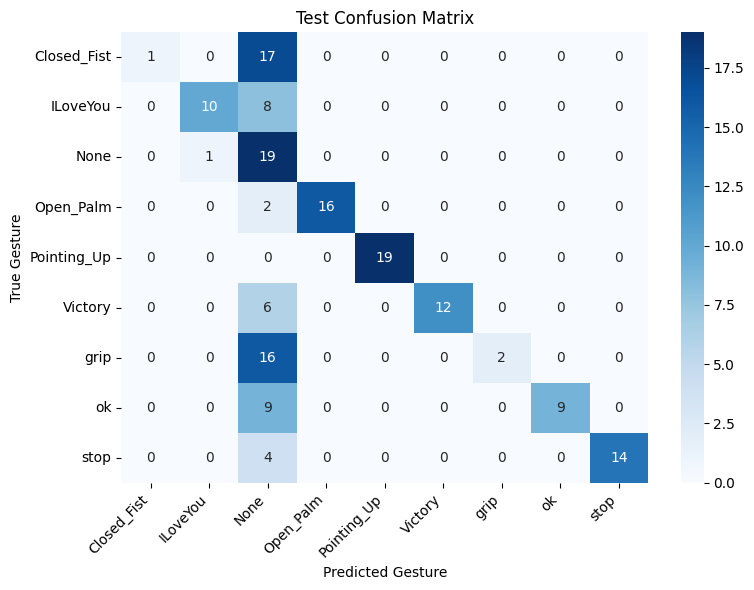

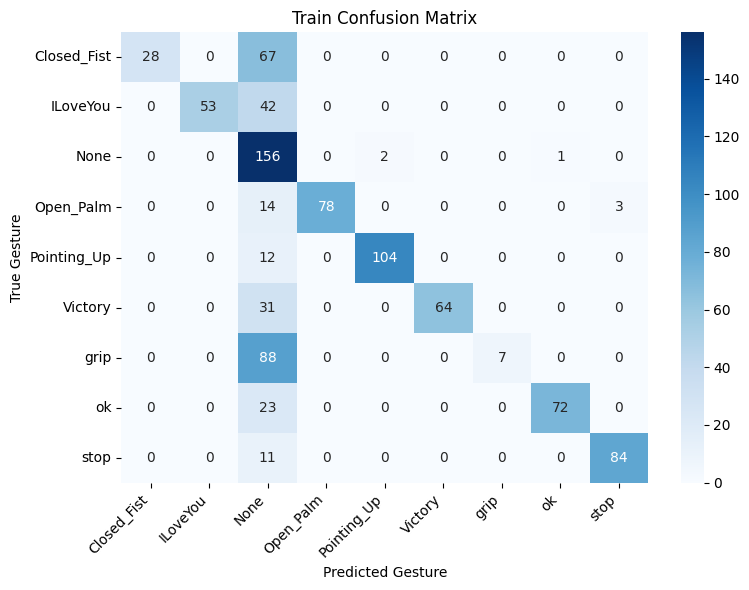

In [ ]:
import sklearn.metrics
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(results_df, title: str):
  y_truth = results_df['label']
  y_pred = results_df['pred']
  classes = sorted(list(results_df['label'].unique()))
  cm = sklearn.metrics.confusion_matrix(
      y_truth, y_pred, labels=classes
  )
  plt.figure(figsize=(8, 6))
  sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
  plt.title(f"{title} Confusion Matrix")
  plt.xlabel("Predicted Gesture")
  plt.xticks(rotation=45, ha='right')
  plt.ylabel("True Gesture")
  plt.grid(False)
  plt.tight_layout()
  plt.show()

plot_confusion_matrix(test_results_df, "Test")
plot_confusion_matrix(train_results_df, "Train")

result
correct      0.666667
not found    0.288889
incorrect    0.044444
Name: proportion, dtype: float64


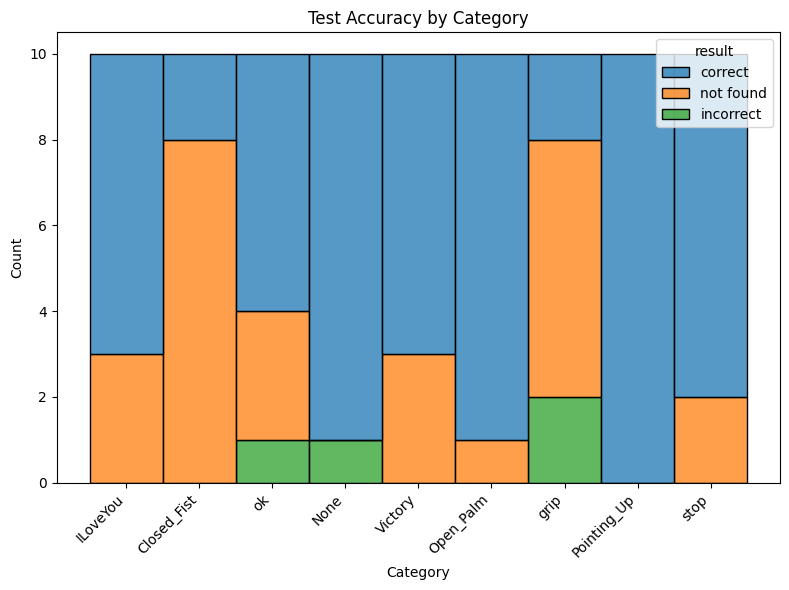

result
correct      0.690278
not found    0.294444
incorrect    0.015278
Name: proportion, dtype: float64


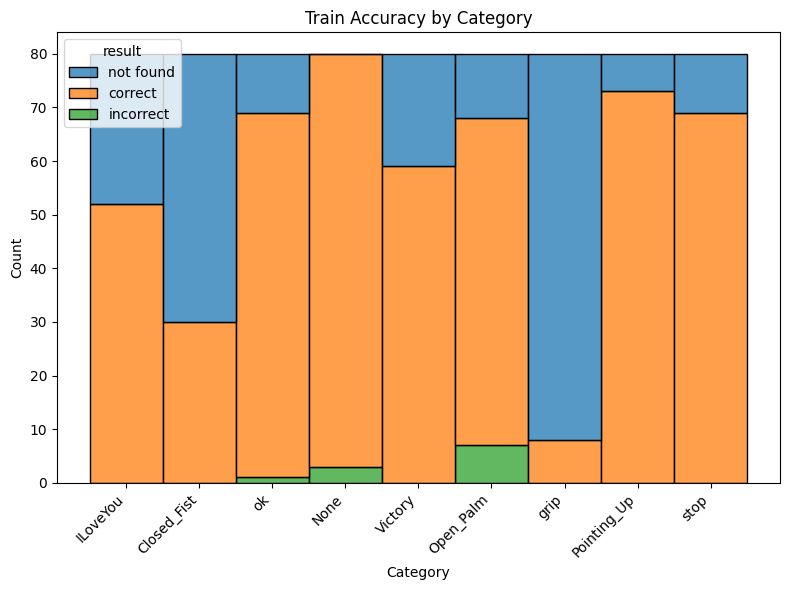

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

def plot_accuracy_by_category(results_df, title: str):
  results_df["result"] = np.where(
      results_df.pred == results_df.label,
      "correct",
      np.where(results_df.pred.isin(["None"]), "not found", "incorrect"),
  )
  print(results_df.result.value_counts(normalize=True))
  plt.figure(figsize=(8, 6))
  sns.histplot(
      data=results_df, x="label", hue="result", multiple="stack", stat="count"
  )
  plt.title(f"{title} Accuracy by Category")
  plt.xlabel("Category")
  plt.ylabel("Count")
  plt.xticks(rotation=45, ha='right')
  plt.tight_layout()
  plt.show()

plot_accuracy_by_category(test_results_df, 'Test')
plot_accuracy_by_category(train_results_df, 'Train')

Predicting on 61 samples from the pre-filtered test set...
61/61 [==============================] - 1s 11ms/step


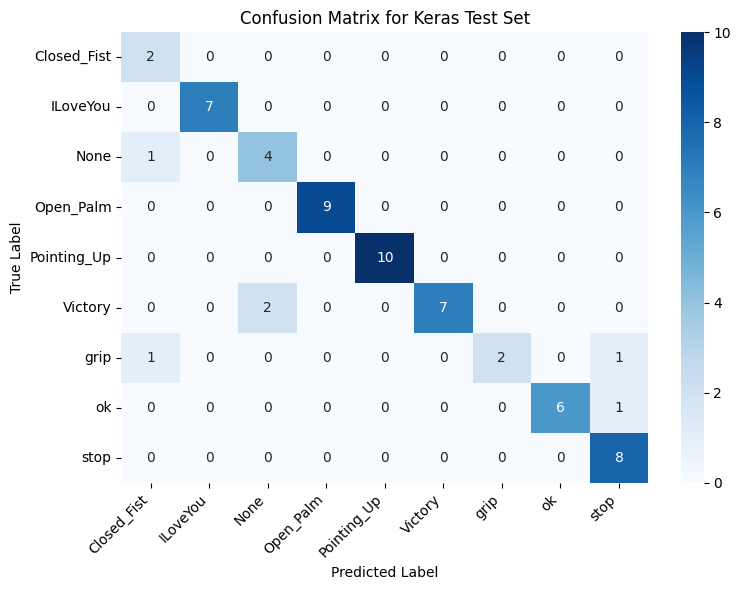

result
correct      0.901639
incorrect    0.065574
not found    0.032787
Name: proportion, dtype: float64


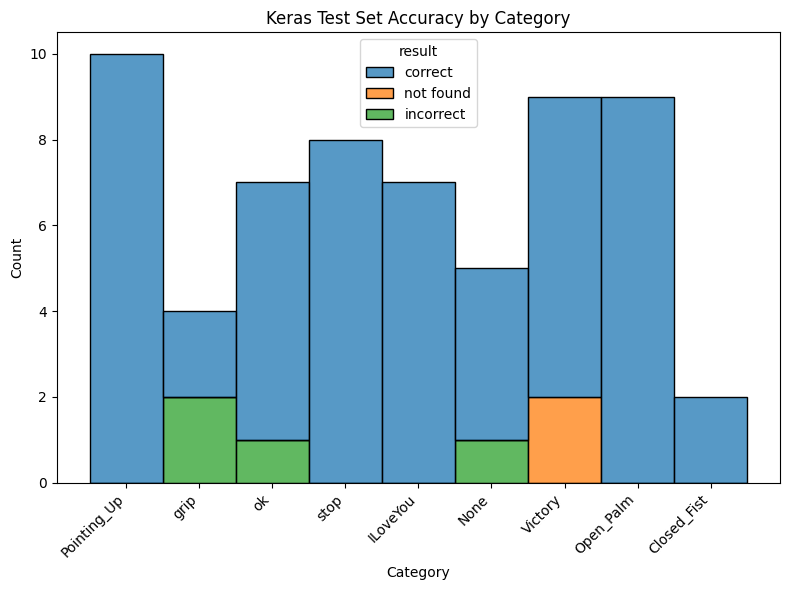

In [120]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

SCORE_THRESHOLD = 0.0 # Confidence threshold for a gesture to be considered valid.

dataset_tf = test_data.gen_tf_dataset()
# dataset_tf = DatasetJustin.from_folder(
#     dirname=test_data_path,
#     hparams=preprocess_params,
#     min_hand_presence_confidence=0.0, # 0 means will not discard any images even if a hand isn't detected
#     min_tracking_confidence=0
# ).gen_tf_dataset()

# 1. Run inference to get raw prediction probabilities
print(f"Predicting on {test_data.size} samples from the pre-filtered test set...")
y_pred_probs = model._model.predict(dataset_tf)

# 2. Get the index of the highest score for each prediction
y_pred_indices = np.argmax(y_pred_probs, axis=1)
y_pred_scores = np.max(y_pred_probs, axis=1)

# 3. Manually apply the score thresholding logic
none_class_index = test_data.label_names.index("None")
final_predictions = []
for i in range(len(y_pred_indices)):
  # If the top score is below the threshold AND the prediction is not "None"
  if y_pred_scores[i] < SCORE_THRESHOLD and y_pred_indices[i] != none_class_index:
    # Override the prediction to be "None"
    final_predictions.append(none_class_index)
  else:
    # Otherwise, keep the original prediction
    final_predictions.append(y_pred_indices[i])

# 4. Extract the true integer labels from the dataset
y_true = np.concatenate([y for x, y in dataset_tf], axis=0)
y_true = np.argmax(y_true, axis=1) # Convert from one-hot to integer labels

# 5. Generate the confusion matrix with the final, thresholded predictions
cm = confusion_matrix(y_true, final_predictions, labels=range(len(test_data.label_names)))

# 6. Plot the confusion matrix with sorted axes
sorted_labels = sorted(test_data.label_names)
label_map = {label: i for i, label in enumerate(test_data.label_names)}
sorted_indices = [label_map[label] for label in sorted_labels]

cm_sorted = cm[sorted_indices, :][:, sorted_indices]

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_sorted,
    annot=True,
    fmt="d",
    xticklabels=sorted_labels,
    yticklabels=sorted_labels,
    cmap='Blues'
)
plt.title("Confusion Matrix for Keras Test Set")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


tf_test_dataset_df = pd.DataFrame({'label': [test_data.label_names[i] for i in y_true],
                                   'pred': [test_data.label_names[i] for i in final_predictions]})
plot_accuracy_by_category(tf_test_dataset_df, 'Keras Test Set')

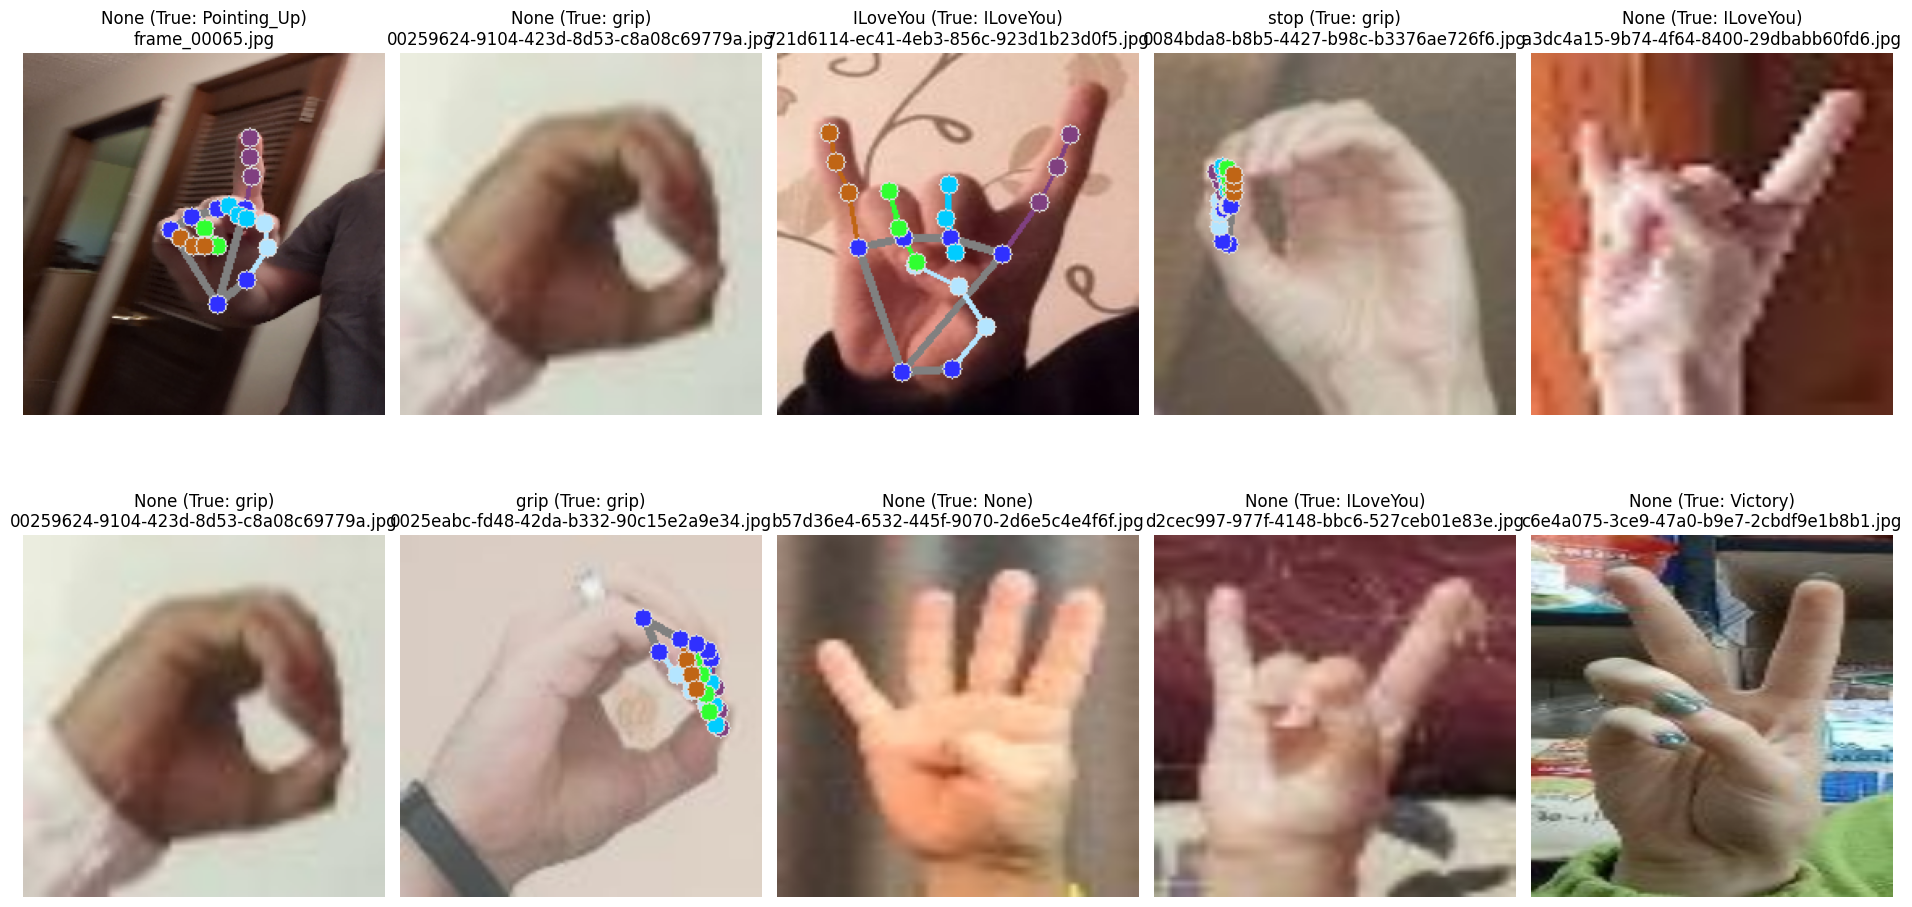

In [119]:
#Show some test sample results
import os

test_samples = np.random.choice(np.asarray(test_image_paths), 10)

with GestureRecognizer.create_from_options(options) as recognizer:
    fig, axarr = plot_recognizer_predictions(test_samples, recognizer, 5)
    for i, (ax, filename) in enumerate(zip(axarr, test_samples)):
        ax.set_title(f"{ax.get_title()}\n{os.path.basename(filename)}")
    fig.set_size_inches(19, 10.5)
    plt.tight_layout()